# Kikuyu LLM - Pre-Training Notebook
**Author:** Peter Gatitu Mwangi | [github.com/bellonbits](https://github.com/bellonbits)

Trains a GPT-style decoder-only transformer on the Kikuyu corpus (Biblica Gikuyu Bible).

**Before running:**
1. Upload `kikuyu_corpus.jsonl` and `kikuyu_bpe_tokenizer.json` to Google Drive
2. Set `Runtime > Change runtime type > GPU > T4`
3. Run all cells top to bottom

**What this notebook covers:**
- Mount Drive and load corpus + tokenizer
- Full transformer architecture (~23M parameters)
- Tokenize corpus and create 90/10 train/val split
- Training loop with cosine LR warmup and gradient clipping
- Checkpoint saving after every epoch (best model kept)
- Loss/perplexity curves
- Quick generation test before SFT

## 1. Setup

In [1]:
!pip install tokenizers -q

import os, math, json, time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tokenizers import Tokenizer
from dataclasses import dataclass
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

print(f'PyTorch  : {torch.__version__}')
print(f'CUDA     : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU      : {torch.cuda.get_device_name(0)}')
    print(f'VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')


PyTorch  : 2.11.0+cu128
CUDA     : True
GPU      : Tesla T4
VRAM     : 15.6 GB


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
# ---- CONFIGURE THESE PATHS ------------------------------------------------
DRIVE_BASE     = '/content/drive/MyDrive/kikuyu_llm'
CORPUS_PATH    = f'{DRIVE_BASE}/kikuyu_corpus.jsonl'
TOKENIZER_PATH = f'{DRIVE_BASE}/kikuyu_bpe_tokenizer.json'
CHECKPOINT_DIR = f'{DRIVE_BASE}/checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

for path in [CORPUS_PATH, TOKENIZER_PATH]:
    exists = os.path.exists(path)
    size   = os.path.getsize(path) / 1024 / 1024 if exists else 0
    status = f'OK ({size:.1f} MB)' if exists else 'NOT FOUND - upload to Drive first'
    print(f'  {os.path.basename(path):<40} {status}')


  kikuyu_corpus.jsonl                      OK (5.0 MB)
  kikuyu_bpe_tokenizer.json                OK (2.3 MB)


## 2. Model Configuration

| Parameter | Value | Notes |
|-----------|-------|-------|
| `d_model` | 384 | Token embedding dimension |
| `n_layers` | 6 | Transformer blocks |
| `n_heads` | 6 | Attention heads per block |
| `d_ff` | 1536 | Feed-forward hidden size (4 x d_model) |
| `vocab_size` | 32000 | From BPE tokenizer |
| `max_seq_len` | 256 | Max tokens per training chunk |
| `batch_size` | 32 | Sequences per gradient step |
| `learning_rate` | 3e-4 | Peak LR (cosine decays to ~0) |
| `warmup_steps` | 500 | Linear LR ramp before cosine |


In [4]:
@dataclass
class KikuyuLLMConfig:
    vocab_size    : int   = 32_000
    pad_token_id  : int   = 0
    bos_token_id  : int   = 2
    eos_token_id  : int   = 3
    d_model       : int   = 384
    n_layers      : int   = 6
    n_heads       : int   = 6
    d_ff          : int   = 1536
    dropout       : float = 0.1
    max_seq_len   : int   = 256
    batch_size    : int   = 32
    learning_rate : float = 3e-4
    weight_decay  : float = 0.1
    max_epochs    : int   = 10
    warmup_steps  : int   = 500
    grad_clip     : float = 1.0

config = KikuyuLLMConfig()

# Rough parameter estimate
n_emb  = config.vocab_size * config.d_model
n_pos  = config.max_seq_len * config.d_model
n_attn = config.n_layers * 4 * config.d_model ** 2
n_ff   = config.n_layers * 2 * config.d_model * config.d_ff
n_ln   = config.n_layers * 4 * config.d_model
total  = n_emb + n_pos + n_attn + n_ff + n_ln
print(f'Estimated parameters: {total/1e6:.1f}M')
print(f'd_model={config.d_model}, n_layers={config.n_layers}, n_heads={config.n_heads}')


Estimated parameters: 23.0M
d_model=384, n_layers=6, n_heads=6


## 3. Transformer Architecture

Decoder-only GPT-style model. Each TransformerBlock applies:
1. **Causal self-attention** - each token attends only to earlier tokens
2. **Feed-forward network** - two linear layers with GELU activation
3. **Residual connections + LayerNorm** - stabilises training depth

Weight tying: the output projection shares weights with the token embedding table,
saving ~12M parameters and improving convergence.

In [5]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.d_model % config.n_heads == 0
        self.n_heads  = config.n_heads
        self.head_dim = config.d_model // config.n_heads
        self.qkv_proj = nn.Linear(config.d_model, 3 * config.d_model)
        self.out_proj = nn.Linear(config.d_model, config.d_model)
        self.dropout  = nn.Dropout(config.dropout)

    def forward(self, x, mask=None):
        B, T, C = x.shape
        qkv = self.qkv_proj(x).reshape(B, T, 3, self.n_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        attn = (q @ k.transpose(-2, -1)) * (self.head_dim ** -0.5)
        if mask is not None:
            attn = attn.masked_fill(mask == 0, float('-inf'))
        attn = F.softmax(attn, dim=-1)
        attn = self.dropout(attn)

        out = (attn @ v).transpose(1, 2).reshape(B, T, C)
        return self.out_proj(out)


class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.fc1     = nn.Linear(config.d_model, config.d_ff)
        self.fc2     = nn.Linear(config.d_ff, config.d_model)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        return self.fc2(self.dropout(F.gelu(self.fc1(x))))


class TransformerBlock(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln1  = nn.LayerNorm(config.d_model)
        self.attn = MultiHeadSelfAttention(config)
        self.ln2  = nn.LayerNorm(config.d_model)
        self.ff   = FeedForward(config)
        self.drop = nn.Dropout(config.dropout)

    def forward(self, x, mask=None):
        x = x + self.drop(self.attn(self.ln1(x), mask))
        x = x + self.drop(self.ff(self.ln2(x)))
        return x


class KikuyuGPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config    = config
        self.token_emb = nn.Embedding(config.vocab_size, config.d_model)
        self.pos_emb   = nn.Embedding(config.max_seq_len, config.d_model)
        self.dropout   = nn.Dropout(config.dropout)
        self.blocks    = nn.ModuleList([TransformerBlock(config) for _ in range(config.n_layers)])
        self.ln_f      = nn.LayerNorm(config.d_model)
        self.head      = nn.Linear(config.d_model, config.vocab_size, bias=False)

        # Weight tying: share token_emb and output projection weights
        self.head.weight = self.token_emb.weight
        self.apply(self._init_weights)

        n_params = sum(p.numel() for p in self.parameters())
        print(f"KikuyuGPT ready: {n_params/1e6:.2f}M parameters")

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, 0.0, 0.02)
            if m.bias is not None: nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Embedding):
            nn.init.normal_(m.weight, 0.0, 0.02)

    def forward(self, input_ids, targets=None):
        B, T   = input_ids.shape
        device = input_ids.device

        x    = self.dropout(
            self.token_emb(input_ids) +
            self.pos_emb(torch.arange(T, device=device))
        )
        mask = torch.tril(torch.ones(T, T, device=device)).unsqueeze(0).unsqueeze(0)

        for block in self.blocks:
            x = block(x, mask)

        logits = self.head(self.ln_f(x))
        loss   = None
        if targets is not None:
            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                targets.view(-1),
                ignore_index=config.pad_token_id
            )
        return {"logits": logits, "loss": loss}

    @torch.no_grad()
    def generate(self, input_ids, max_new_tokens=150, temperature=0.8,
                 top_k=50, top_p=0.9, eos_token_id=None):
        self.eval()
        eos_id = eos_token_id or self.config.eos_token_id
        for _ in range(max_new_tokens):
            ctx    = input_ids[:, -self.config.max_seq_len:]
            logits = self.forward(ctx)["logits"][:, -1, :] / temperature

            # Top-K
            if top_k > 0:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = float('-inf')

            # Top-P (nucleus)
            if top_p < 1.0:
                s_logits, s_idx = torch.sort(logits, descending=True)
                cum_p = torch.cumsum(F.softmax(s_logits, dim=-1), dim=-1)
                remove = cum_p > top_p
                remove[:, 1:] = remove[:, :-1].clone(); remove[:, 0] = False
                logits[remove.scatter(1, s_idx, remove)] = float('-inf')

            next_tok  = torch.multinomial(F.softmax(logits, dim=-1), 1)
            input_ids = torch.cat([input_ids, next_tok], dim=1)
            if next_tok.item() == eos_id:
                break
        return input_ids

## 4. Load Corpus & Build Dataset

The full corpus is tokenized into one long flat tensor of token IDs,
then sliced into 256-token chunks for training.
Each chunk yields `(input, target)` where target = input shifted left by 1 position.
This is the standard next-token prediction objective.

In [6]:
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Training on: {device}')

tokenizer = Tokenizer.from_file(TOKENIZER_PATH)
config.vocab_size = tokenizer.get_vocab_size()
print(f'Tokenizer loaded | vocab: {config.vocab_size:,}')


Training on: cuda
Tokenizer loaded | vocab: 32,000


In [7]:
print('Tokenising corpus...')
t0      = time.time()
all_ids = []

with open(CORPUS_PATH, 'r', encoding='utf-8') as f:
    for line in tqdm(f, desc='Documents'):
        doc = json.loads(line)
        enc = tokenizer.encode(doc['text'])
        all_ids.extend(enc.ids)

all_ids = torch.tensor(all_ids, dtype=torch.long)
print(f'Done in {time.time()-t0:.0f}s')
print(f'Total tokens  : {len(all_ids):,}')
print(f'Unique tokens : {len(set(all_ids.tolist())):,} / {config.vocab_size:,}')
print(f'Coverage      : {len(set(all_ids.tolist()))/config.vocab_size*100:.1f}% of vocab seen')


Tokenising corpus...


Documents: 0it [00:00, ?it/s]

Done in 9s
Total tokens  : 886,288
Unique tokens : 31,509 / 32,000
Coverage      : 98.5% of vocab seen


In [8]:
class KikuyuTextDataset(Dataset):
    """
    Slices a flat token sequence into fixed-length chunks.
    __getitem__ returns (input_ids, targets) where targets = input_ids shifted left by 1.
    Example for seq_len=4:
      tokens  : [A B C D E]
      input   : [A B C D]
      targets : [B C D E]   <-- model must predict each next token
    """
    def __init__(self, token_ids: torch.Tensor, seq_len: int):
        self.token_ids = token_ids
        self.seq_len   = seq_len
        self.n_chunks  = (len(token_ids) - 1) // seq_len

    def __len__(self):
        return self.n_chunks

    def __getitem__(self, idx):
        start = idx * self.seq_len
        chunk = self.token_ids[start : start + self.seq_len + 1]
        return chunk[:-1], chunk[1:]


# 90/10 split
split_idx     = int(len(all_ids) * 0.9)
train_dataset = KikuyuTextDataset(all_ids[:split_idx], config.max_seq_len)
val_dataset   = KikuyuTextDataset(all_ids[split_idx:], config.max_seq_len)

train_loader  = DataLoader(train_dataset, batch_size=config.batch_size,
                           shuffle=True,  num_workers=2, pin_memory=True)
val_loader    = DataLoader(val_dataset,   batch_size=config.batch_size,
                           shuffle=False, num_workers=2, pin_memory=True)

print(f"Train : {len(train_dataset):,} chunks  ({len(train_dataset)*config.max_seq_len/1e6:.1f}M tokens)")
print(f"Val   : {len(val_dataset):,} chunks")
print(f"Steps/epoch: {len(train_loader):,}")

Train : 3,115 chunks  (0.8M tokens)
Val   : 346 chunks
Steps/epoch: 98


## 5. Training

**Learning rate schedule:**
- Steps 0-500: linear warmup from 0 to peak LR (3e-4)
- Steps 500+: cosine decay from peak LR to ~0

**Gradient clipping:** if total gradient norm > 1.0, scale all gradients down.
Prevents rare bad batches from destroying training.

**Checkpointing:** saves after every epoch; `best_model.pt` always holds the lowest val loss.

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = KikuyuGPT(config).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config.learning_rate,
    weight_decay=config.weight_decay,
    betas=(0.9, 0.95)
)

total_steps = len(train_loader) * config.max_epochs

def get_lr(step):
    if step < config.warmup_steps:
        return config.learning_rate * step / config.warmup_steps
    progress = (step - config.warmup_steps) / max(total_steps - config.warmup_steps, 1)
    return config.learning_rate * 0.5 * (1.0 + math.cos(math.pi * progress))

print(f'Total steps  : {total_steps:,}')
print(f'Warmup steps : {config.warmup_steps}')
print(f'Peak LR      : {config.learning_rate}')


KikuyuGPT ready: 23.03M parameters
Total steps  : 980
Warmup steps : 500
Peak LR      : 0.0003


In [10]:
history     = {"train_loss": [], "val_loss": []}
global_step = 0
best_val    = float("inf")
start_epoch = 0

# --- To resume from a checkpoint, uncomment: ---
# ckpt = torch.load(f"{CHECKPOINT_DIR}/best_model.pt", map_location=device)
# model.load_state_dict(ckpt["model_state_dict"])
# optimizer.load_state_dict(ckpt["optimizer_state_dict"])
# start_epoch = ckpt["epoch"]
# best_val    = ckpt["val_loss"]
# global_step = ckpt["global_step"]
# print(f"Resumed from epoch {start_epoch}, val_loss={best_val:.4f}")
# ------------------------------------------------

print("Starting pre-training...\n")

for epoch in range(start_epoch, config.max_epochs):

    # ---- TRAIN ----------------------------------------------------------
    model.train()
    epoch_loss = 0.0
    n_batches  = 0
    t_start    = time.time()

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{config.max_epochs} [train]")
    for input_ids, targets in pbar:
        input_ids = input_ids.to(device)
        targets   = targets.to(device)

        # Set LR for this step
        lr = get_lr(global_step)
        for g in optimizer.param_groups:
            g["lr"] = lr

        # Forward + loss
        loss = model(input_ids, targets)["loss"]

        # Backward
        optimizer.zero_grad(set_to_none=True)
        loss.backward()

        # Clip gradients
        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), config.grad_clip)

        optimizer.step()

        epoch_loss  += loss.item()
        n_batches   += 1
        global_step += 1

        pbar.set_postfix(loss=f"{loss.item():.4f}", lr=f"{lr:.1e}", gnorm=f"{grad_norm:.2f}")

    avg_train = epoch_loss / n_batches

    # ---- VALIDATE -------------------------------------------------------
    model.eval()
    val_loss = 0.0
    n_val    = 0
    with torch.no_grad():
        for input_ids, targets in tqdm(val_loader, desc=f"Epoch {epoch+1} [val]  "):
            input_ids = input_ids.to(device)
            targets   = targets.to(device)
            val_loss += model(input_ids, targets)["loss"].item()
            n_val    += 1

    avg_val = val_loss / n_val

    # Perplexity: e^loss. PPL=100 means model is choosing among ~100 equally likely tokens
    train_ppl = math.exp(min(avg_train, 10))
    val_ppl   = math.exp(min(avg_val,   10))
    elapsed   = (time.time() - t_start) / 60

    history["train_loss"].append(avg_train)
    history["val_loss"].append(avg_val)

    print(f"\nEpoch {epoch+1:>2}/{config.max_epochs} | "
          f"Train: {avg_train:.4f} (PPL {train_ppl:.0f}) | "
          f"Val: {avg_val:.4f} (PPL {val_ppl:.0f}) | "
          f"{elapsed:.1f} min")

    # ---- CHECKPOINT -----------------------------------------------------
    ckpt = {
        "epoch"               : epoch + 1,
        "global_step"         : global_step,
        "model_state_dict"    : model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "train_loss"          : avg_train,
        "val_loss"            : avg_val,
        "config"              : config.__dict__,
    }
    # Always save latest epoch
    torch.save(ckpt, f"{CHECKPOINT_DIR}/epoch_{epoch+1:02d}.pt")

    # Save best separately
    if avg_val < best_val:
        best_val = avg_val
        torch.save(ckpt, f"{CHECKPOINT_DIR}/best_model.pt")
        print(f"  --> New best model saved (val_loss={best_val:.4f})")

print(f"\nPre-training complete.")
print(f"Best val loss : {best_val:.4f}  (PPL {math.exp(min(best_val,10)):.0f})")

Starting pre-training...



Epoch 1/10 [train]:   0%|          | 0/98 [00:00<?, ?it/s]

Epoch 1 [val]  :   0%|          | 0/11 [00:00<?, ?it/s]


Epoch  1/10 | Train: 9.8365 (PPL 18704) | Val: 9.0461 (PPL 8485) | 0.7 min
  --> New best model saved (val_loss=9.0461)


Epoch 2/10 [train]:   0%|          | 0/98 [00:00<?, ?it/s]

...

Epoch 9 [val]  :   0%|          | 0/11 [00:00<?, ?it/s]


Epoch  9/10 | Train: 5.4925 (PPL 243) | Val: 6.4515 (PPL 634) | 0.7 min
  --> New best model saved (val_loss=6.4515)


Epoch 10/10 [train]:   0%|          | 0/98 [00:00<?, ?it/s]

Epoch 10 [val]  :   0%|          | 0/11 [00:00<?, ?it/s]


Epoch 10/10 | Train: 5.4368 (PPL 230) | Val: 6.4492 (PPL 632) | 0.7 min
  --> New best model saved (val_loss=6.4492)

Pre-training complete.
Best val loss : 6.4492  (PPL 632)


## 6. Training Curves

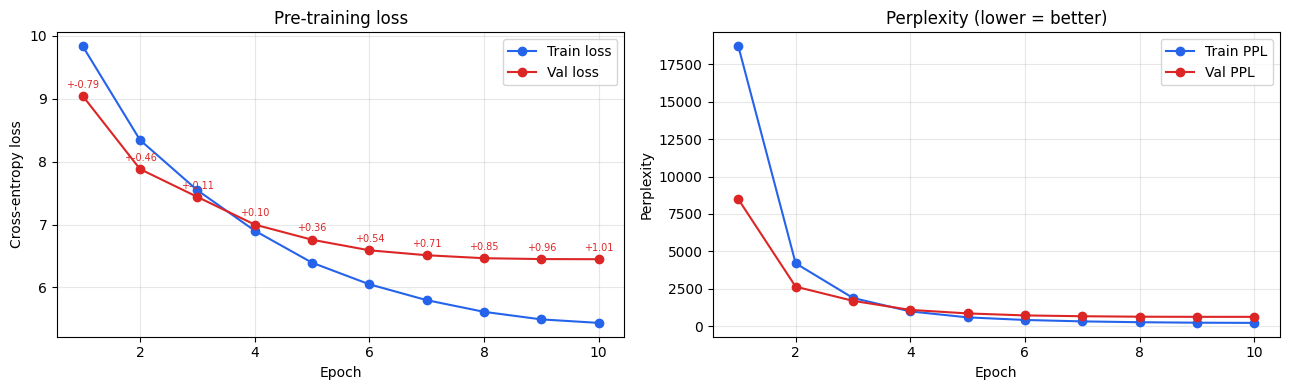

Saved training_curves.png to Drive

Interpretation:
  Val loss improvement : 2.5969
  Val-Train gap (last) : 1.0124  (watch for overfitting)
  Advice: gap is large. Add more data or increase dropout slightly.


In [11]:
epochs_ran = list(range(1, len(history["train_loss"]) + 1))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# -- Loss --
ax1.plot(epochs_ran, history["train_loss"], "o-", label="Train loss", color="#2563eb")
ax1.plot(epochs_ran, history["val_loss"],   "o-", label="Val loss",   color="#dc2626")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Cross-entropy loss")
ax1.set_title("Pre-training loss"); ax1.legend(); ax1.grid(alpha=0.3)

# Annotate val-train gap (measure of overfitting)
for e, tl, vl in zip(epochs_ran, history["train_loss"], history["val_loss"]):
    gap = vl - tl
    ax1.annotate(f"+{gap:.2f}", (e, vl),
                 textcoords="offset points", xytext=(0, 6),
                 fontsize=7, ha="center", color="#dc2626")

# -- Perplexity --
train_ppl = [math.exp(min(l, 10)) for l in history["train_loss"]]
val_ppl   = [math.exp(min(l, 10)) for l in history["val_loss"]]
ax2.plot(epochs_ran, train_ppl, "o-", label="Train PPL", color="#2563eb")
ax2.plot(epochs_ran, val_ppl,   "o-", label="Val PPL",   color="#dc2626")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Perplexity")
ax2.set_title("Perplexity (lower = better)"); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{CHECKPOINT_DIR}/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved training_curves.png to Drive")

# Diagnostics
print("\nInterpretation:")
if len(history["train_loss"]) > 1:
    improvement = history["val_loss"][0] - history["val_loss"][-1]
    gap_last    = history["val_loss"][-1] - history["train_loss"][-1]
    print(f"  Val loss improvement : {improvement:.4f}")
    print(f"  Val-Train gap (last) : {gap_last:.4f}  {'(watch for overfitting)' if gap_last > 0.5 else '(healthy)'}")
    if gap_last > 0.8:
        print("  Advice: gap is large. Add more data or increase dropout slightly.")
    elif history["val_loss"][-1] > 6.0:
        print("  Advice: still high loss. Consider more epochs or smaller LR.")
    else:
        print("  Model is learning well. Proceed to SFT.")

## 7. Quick Inference Test

Tests raw text continuation from the pre-trained model **before SFT**.
At this stage the model generates plausible Kikuyu text but does not
respond to questions in chat format - that is what SFT is for.

In [12]:
# Load best checkpoint
ckpt = torch.load(f"{CHECKPOINT_DIR}/best_model.pt", map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

BOS_ID = tokenizer.token_to_id("<bos>") or 2
EOS_ID = tokenizer.token_to_id("<eos>") or 3

def generate_text(prompt: str, max_new_tokens: int = 80,
                  temperature: float = 0.8, top_k: int = 50) -> str:
    enc       = tokenizer.encode(prompt)
    input_ids = torch.tensor([[BOS_ID] + enc.ids], dtype=torch.long).to(device)
    with torch.no_grad():
        out = model.generate(input_ids, max_new_tokens=max_new_tokens,
                             temperature=temperature, top_k=top_k, top_p=0.9,
                             eos_token_id=EOS_ID)
    new_ids = out[0][len(enc.ids)+1:].tolist()
    if EOS_ID in new_ids:
        new_ids = new_ids[:new_ids.index(EOS_ID)]
    return tokenizer.decode(new_ids)


test_prompts = [
    "Ngai niombire iguru na thi",
    "Muthenya wa mbere",
    "Nake Jesu",
    "Agikuyu",
    "Kirinyaga",
    "Maundu ma Ngai",
]

print("=" * 65)
print("RAW TEXT GENERATION  (pre-SFT, next-token prediction only)")
print("=" * 65)
for prompt in test_prompts:
    out = generate_text(prompt, max_new_tokens=60, temperature=0.8)
    print(f"\n  Prompt   : {prompt}")
    print(f"  Generated: {out}")
    print("-" * 65)

# Temperature sweep
print("\nTEMPERATURE SWEEP")
print("=" * 65)
prompt = "Ngai niombire"
for temp in [0.3, 0.6, 0.9, 1.2]:
    out = generate_text(prompt, max_new_tokens=40, temperature=temp)
    label = {0.3: "focused", 0.6: "balanced", 0.9: "creative", 1.2: "wild"}[temp]
    print(f"  temp={temp}  ({label}): {out}")

RAW TEXT GENERATION  (pre-SFT, next-token prediction only)

  Prompt   : Ngai niombire iguru na thi
  Generated: Mathayo 2510 2 Maũndũ ma Jehova ekuuga atĩrĩ: 2 Athamaki 16 1 Maũndũ ma Tene 355 Jeremia 18 Ningĩ Samũeli 16 Ningĩ Jakubu na rũhiũ rwa njora rwa njora. 17 No rĩrĩ, wee mũthamaki wa nyina na andũ a Isiraeli othe a Isiraeli na arĩa maarĩ hamwe na mbũtũ cia mbaara kũu igũrũ o wothe wa
-----------------------------------------------------------------

  Prompt   : Muthenya wa mbere
  Generated: Ndari 669 Jeremia 6 Jeremia 242 Isaia 16 No rĩrĩ, andũ arĩa matũũraga itũũra inene rĩa andũ a nyũmba ya bũrũri ũcio wa Babuloni nĩ ũndũ wa Babuloni na andũ a Moabi marĩ hamwe na andũ a Misiri arĩa aaganu,
o na arĩa maikaraga na arĩa marĩ na anene a Juda arĩa maarĩ atongoria a itũũra rĩrĩa
-----------------------------------------------------------------

  Prompt   : Nake Jesu
  Generated: Thaama 2 Athamaki 217 Mathayo 14 Ningĩ Joshua agĩthiĩ Jerusalemu kuuma bũrũri ũcio o na wa Misiri, k

## 8. Next Steps - SFT

The pre-trained model knows Kikuyu language and grammar but cannot hold a conversation.
The next notebook (SFT) will fine-tune it on the `kikuyu_sft_combined.jsonl` dataset
to make it respond to questions in chat format.

**Files to carry into the SFT notebook:**
- `checkpoints/best_model.pt` (pre-trained weights)
- `kikuyu_bpe_tokenizer.json`
- `kikuyu_sft_combined.jsonl`

In [13]:
# Summary
ckpt = torch.load(f'{CHECKPOINT_DIR}/best_model.pt', map_location='cpu')
print('=' * 55)
print('PRE-TRAINING SUMMARY')
print('=' * 55)
print(f"  Best epoch    : {ckpt['epoch']}")
print(f"  Best val loss : {ckpt['val_loss']:.4f}")
print(f"  Perplexity    : {math.exp(min(ckpt['val_loss'],10)):.0f}")
print(f"  Global steps  : {ckpt['global_step']:,}")
print(f"  Checkpoint    : {CHECKPOINT_DIR}/best_model.pt")
print()
print('Checkpoints saved:')
for f in sorted(os.listdir(CHECKPOINT_DIR)):
    if f.endswith('.pt'):
        sz = os.path.getsize(os.path.join(CHECKPOINT_DIR, f)) / 1024 / 1024
        print(f'  {f:<25} {sz:.1f} MB')
print('\nReady for SFT notebook.')


PRE-TRAINING SUMMARY
  Best epoch    : 10
  Best val loss : 6.4492
  Perplexity    : 632
  Global steps  : 980
  Checkpoint    : /content/drive/MyDrive/kikuyu_llm/checkpoints/best_model.pt

Checkpoints saved:
  best_model.pt             263.7 MB
  epoch_01.pt               263.7 MB
  epoch_02.pt               263.7 MB
  epoch_03.pt               263.7 MB
  epoch_04.pt               263.7 MB
  epoch_05.pt               263.7 MB
  epoch_06.pt               263.7 MB
  epoch_07.pt               263.7 MB
  epoch_08.pt               263.7 MB
  epoch_09.pt               263.7 MB
  epoch_10.pt               263.7 MB

Ready for SFT notebook.
